# World Happiness 2015–2019: Drivers, Disparities, and Statistical Tests

_A reproducible enquiry into what moves the World Happiness Score across countries and years, enriched with World Bank and REST Countries data._

### Contents

1. [Introduction](#1.-Introduction)
2. [Data Sources & Acquisition](#2.-Data-Sources-&-Acquisition)
3. [Data Wrangling Pipeline](#3.-Data-Wrangling-Pipeline)
    - 3.1 [Schema reconciliation across years](#3.1-Schema-reconciliation-across-years)
    - 3.2 [Country-name normalization (ISO-3)](#3.2-Country-name-normalization-(ISO-3))
    - 3.3 [Enrichment from World Bank](#3.3-Enrichment-from-World-Bank)
    - 3.4 [Enrichment from REST Countries](#3.4-Enrichment-from-REST-Countries)
    - 3.5 [Missing values & outliers](#3.5-Missing-values-&-outliers)
4. [Exploratory Analysis & Visualization](#4.-Exploratory-Analysis-&-Visualization)
    - 4.1 [Global distribution (2019)](#4.1-Global-distribution-(2019))
    - 4.2 [Regional comparison](#4.2-Regional-comparison)
    - 4.3 [Time evolution 2015 to 2019](#4.3-Time-evolution-2015-to-2019)
    - 4.4 [Correlation matrix](#4.4-Correlation-matrix)
5. [Hypothesis Testing](#5.-Hypothesis-Testing)
    - 5.1 [H1 — Western Europe vs Sub-Saharan Africa (independent t-test)](#5.1-H1-—-Western-Europe-vs-Sub-Saharan-Africa)
    - 5.2 [H2 — GDP per capita predicts happiness (Pearson r)](#5.2-H2-—-GDP-per-capita-predicts-happiness)
    - 5.3 [H3 — Income group vs happiness class (chi-squared)](#5.3-H3-—-Income-group-vs-happiness-class)
6. [Conclusions](#6.-Conclusions)
7. [Summary](#7.-Summary)
8. [References](#8.-References)

## 1. Introduction

Every spring the **World Happiness Report** publishes a single numeric **happiness score** per country, derived from the Gallup World Poll's Cantril ladder question ("Imagine a ladder, with steps numbered from 0 at the bottom to 10 at the top — the top represents the best possible life for you…"). Alongside the score the report attributes the country's position to six contributing factors: GDP per capita, social support, healthy life expectancy, freedom to make life choices, generosity, and perceptions of corruption.

While the report itself summarises results, it stops short of running formal statistical tests across the five-year window 2015–2019. This notebook closes that gap and asks three concrete questions:

- **H1.** Does the average happiness score in **Western Europe** differ significantly from that in **Sub-Saharan Africa** (independent two-sample t-test)?
- **H2.** Is national happiness linearly associated with **GDP per capita PPP** when measured against an external source — the World Bank — instead of the WHR's internal estimate (Pearson correlation)?
- **H3.** Is a country's **World Bank income group** (Low / Lower-middle / Upper-middle / High) **independent** of its happiness class (above vs. below the global median) (chi-squared test of independence)?

All hypothesis tests use $\alpha = 0.05$. The pipeline that produces the analysis-ready table is documented in section 3 and lives entirely under [`src/`](./src), so the notebook itself stays narrative and short. To re-run end to end, execute every cell top-to-bottom inside the project's Docker image.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.data import happiness, reconcile, restcountries, worldbank, pipeline
from src.charts import distributions, relationships, geographic, timeseries

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 140)

## 2. Data Sources & Acquisition

Three independent sources feed the analysis. Two of them are remote APIs, both queried at notebook start and cached on disk so subsequent runs work offline.

| # | Source | Coverage | Access | Cache location |
|---|---|---|---|---|
| 1 | World Happiness Report 2015–2019 (Kaggle CSV dump) | One CSV per year, 155–158 countries each | Local files | `data/raw/world-happines-2015-2019/` |
| 2 | World Bank Open Data | GDP per capita PPP, unemployment, income group | `wbgapi` Python client | `data/raw/worldbank/` |
| 3 | REST Countries v3.1 | Region, subregion, population | `requests.get('https://restcountries.com/v3.1/all')` | `data/raw/restcountries/` |

We start by inspecting one raw WHR CSV to motivate the schema drift discussion in §3.1.

In [2]:
raw_dir = Path('data/raw/world-happines-2015-2019')
raw_2015 = pd.read_csv(raw_dir / '2015.csv')
raw_2018 = pd.read_csv(raw_dir / '2018.csv')

print('2015 columns:', list(raw_2015.columns))
print('2018 columns:', list(raw_2018.columns))
print('2015 shape:', raw_2015.shape, ' 2018 shape:', raw_2018.shape)

2015 columns: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']
2018 columns: ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']
2015 shape: (158, 12)  2018 shape: (156, 9)


## 3. Data Wrangling Pipeline

The end-to-end build is encapsulated in `pipeline.build_dataset()`. The next five subsections walk through what it does, in the same order, with intermediate frames so the transformation is auditable.

```text
raw 5 yearly CSVs ----+
                      |
                      v
         happiness.load_all  ---+
                                |
         reconcile.normalize_names
                                |
 worldbank.fetch_*  ----------> + <- restcountries.fetch_country_metadata
                                |
                                v
             data/processed/happiness_enriched.csv
```

### 3.1 Schema reconciliation across years

The five CSVs use **four different naming conventions**:

- 2015 — `Happiness Score`, `Economy (GDP per Capita)`, `Family`, `Health (Life Expectancy)`, `Trust (Government Corruption)`…
- 2016 — same as 2015 but `Standard Error` becomes a confidence-interval pair
- 2017 — dot-separated names (`Happiness.Score`, `Economy..GDP.per.Capita.`, `Whisker.high`)
- 2018 / 2019 — short modern names (`Score`, `GDP per capita`, `Social support`, `Healthy life expectancy`)

`happiness.load_year(year)` knows the per-year mapping and returns a frame in the canonical schema `(country, year, score, gdp, social_support, life_expectancy, freedom, generosity, corruption)`. `happiness.load_all()` concatenates the five frames into a single long table.

In [3]:
happiness_long = happiness.load_all()
print('long-format shape:', happiness_long.shape)
print('rows per year:')
print(happiness_long.groupby('year').size().to_string())
happiness_long.head()

long-format shape: (782, 9)
rows per year:
year
2015    158
2016    157
2017    155
2018    156
2019    156


,country,year,score,gdp,social_support,life_expectancy,freedom,generosity,corruption
0,Afghanistan,2015,3.575,0.31982,0.30285,0.30335,0.23414,0.36510,0.09719
1,Albania,2015,4.959,0.87867,0.80434,0.81325,0.35733,0.14272,0.06413
2,Algeria,2015,5.605,0.93929,1.07772,0.61766,0.28579,0.07822,0.17383
3,Angola,2015,4.033,0.75778,0.86040,0.16683,0.10384,0.12344,0.07122
4,Argentina,2015,6.574,1.05351,1.24823,0.78723,0.44974,0.11451,0.08484


### 3.2 Country-name normalization (ISO-3)

Names diverge between sources (`United States` vs `United States of America`, `Hong Kong S.A.R., China` vs `Hong Kong`, `Czech Republic` vs `Czechia`). To dodge those landmines every join in the pipeline happens on the **ISO 3166-1 alpha-3 code**, produced by `reconcile.normalize_names`, which delegates to the `country_converter` library and falls back to a manual `OVERRIDES` dict if needed.

Verification: every name in the WHR corpus must resolve. Anything that doesn't would surface as `NaN` in `country_iso3`.

In [4]:
happiness_iso = reconcile.normalize_names(happiness_long, col='country')
n_unresolved = happiness_iso['country_iso3'].isna().sum()
print(f'rows: {len(happiness_iso)}, unresolved country names: {n_unresolved}')
happiness_iso[['country', 'country_iso3', 'year', 'score']].head()

rows: 782, unresolved country names: 0


,country,country_iso3,year,score
0,Afghanistan,AFG,2015,3.575
1,Albania,ALB,2015,4.959
2,Algeria,DZA,2015,5.605
3,Angola,AGO,2015,4.033
4,Argentina,ARG,2015,6.574


### 3.3 Enrichment from World Bank

From the World Bank we pull two indicators and one categorical attribute:

- `NY.GDP.PCAP.PP.CD` — **GDP per capita, PPP** (current international $). Comparable across countries; complements the WHR's internal `gdp` factor (which is already a log-transformed contribution to the score, not the raw figure).
- `SL.UEM.TOTL.ZS` — **Unemployment**, total (% of total labor force, ILO modelled estimate).
- **Income group** — World Bank classification (`Low income`, `Lower middle income`, `Upper middle income`, `High income`). Required for H3.

All three calls are cached as CSVs under `data/raw/worldbank/`.

In [5]:
wb_gdp = worldbank.fetch_gdp_per_capita_ppp(years=range(2015, 2020))
wb_unemp = worldbank.fetch_unemployment(years=range(2015, 2020))
wb_income = worldbank.fetch_income_groups()

print('GDP PPP rows:', len(wb_gdp), ' unemployment rows:', len(wb_unemp), ' income groups:', len(wb_income))
print('income group counts:')
print(wb_income['income_group'].value_counts().to_string())

GDP PPP rows: 1330  unemployment rows: 1330  income groups: 215
income group counts:
income_group
High income            86
Upper middle income    54
Lower middle income    50
Low income             25


### 3.4 Enrichment from REST Countries

REST Countries gives us the **region / subregion / population** that the WHR drops from 2017 onwards. The query goes against `https://restcountries.com/v3.1/all?fields=name,cca3,region,subregion,population` and is cached as a single JSON blob.

It also supplies the `subregion` column we need to slice Western Europe and Sub-Saharan Africa for **H1**.

In [6]:
rc_meta = restcountries.fetch_country_metadata()
print('REST Countries rows:', len(rc_meta))
print('regions:')
print(rc_meta['region'].value_counts().to_string())
rc_meta.head()

REST Countries rows: 250
regions:
region
Africa       59
Americas     56
Europe       53
Asia         50
Oceania      27
Antarctic     5


,country_iso3,name_common,region,subregion,population
0,ABW,Aruba,Americas,Caribbean,107566
1,AFG,Afghanistan,Asia,Southern Asia,43844000
2,AGO,Angola,Africa,Middle Africa,36170961
3,AIA,Anguilla,Americas,Caribbean,16010
4,ALA,Åland Islands,Europe,Northern Europe,30654


### 3.5 Missing values & outliers

`pipeline.build_dataset()` performs the four left joins (happiness ⊓ GDP ⊓ unemployment ⊓ income group ⊓ REST Countries metadata) and writes the result to `data/processed/happiness_enriched.csv`.

Left joins keep every WHR row even when a complementary source has no entry for that country. We expect a handful of missing values for:

- **Taiwan and Palestinian Territories** — not present in the World Bank classification.
- **Recent micro-states** — occasionally missing from REST Countries.
- **Unemployment** — some Gulf states and small island nations are not in the ILO modelled estimates.

We **do not impute** the missing values: each hypothesis test below filters its inputs with `dropna` so that exclusions are explicit and reproducible.

In [7]:
df = pipeline.build_dataset(use_cache=True)
print('enriched shape:', df.shape)
print('\nNaNs per column:')
print(df.isna().sum().sort_values(ascending=False).to_string())

enriched shape: (782, 17)

NaNs per column:
gdp_ppp            21
income_group       15
unemployment       10
population          5
subregion           5
region              5
name_common         5
corruption          1
year                0
country_iso3        0
generosity          0
freedom             0
life_expectancy     0
social_support      0
gdp                 0
score               0
country             0


In [8]:
# Outlier sanity check: countries whose 2019 score is more than 2 SD from the global mean
scores_2019 = df.query('year == 2019')['score']
mu, sigma = scores_2019.mean(), scores_2019.std(ddof=1)
outliers = df.query('year == 2019').assign(z=(df.query('year == 2019')['score'] - mu) / sigma)
outliers = outliers[outliers['z'].abs() > 2][['country', 'score', 'z', 'region']].sort_values('score')
print(f'2019 mean = {mu:.3f}, sd = {sigma:.3f}')
outliers

2019 mean = 5.407, sd = 1.113


,country,score,z,region
754,South Sudan,2.853,-2.294538,Africa
650,Central African Republic,3.083,-2.087912,Africa
669,Finland,7.769,2.121877,Europe


## 4. Exploratory Analysis & Visualization

### 4.1 Global distribution (2019)

Before doing any group comparison, we look at the **global distribution** of the 2019 happiness score. The histogram below shows it is approximately bell-shaped, lightly **left-skewed** (a long tail of unhappy countries pulling the mean below the median), with the central mass between roughly 4 and 6.5. This rough symmetry is what later allows us to lean on parametric tests in section 5 without too many caveats.

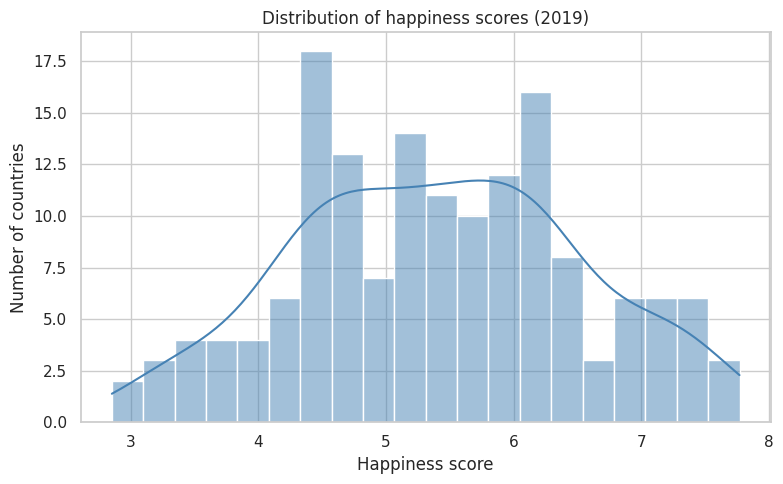

In [9]:
distributions.histogram_score(df, year=2019)
plt.show()

### 4.2 Regional comparison

Splitting the 2019 score by REST Countries' **region** field separates Europe and Oceania (medians around 6.0\u20136.5) from Africa (median around 4.5). Asia and the Americas straddle the global median. The boxplot also exposes Europe's wide internal range \u2014 Western Europe sits at the very top, Eastern Europe trails closer to the global mean \u2014 which previews the subregion split used by **H1**.

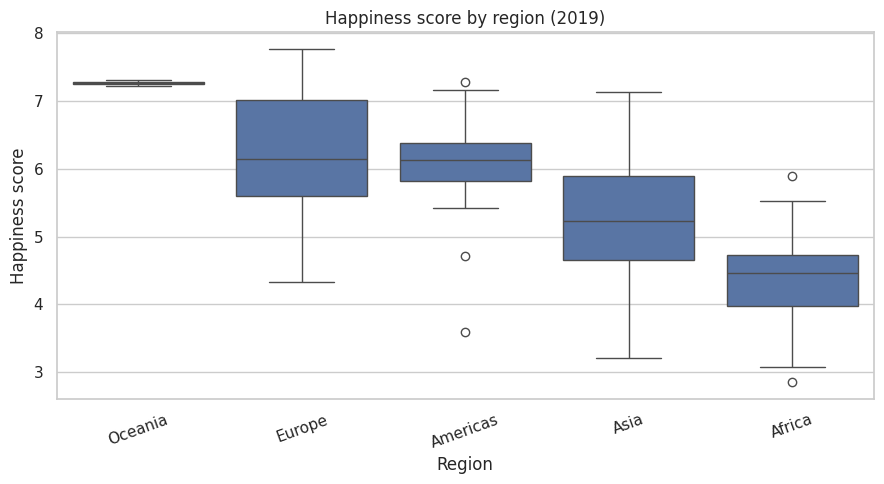

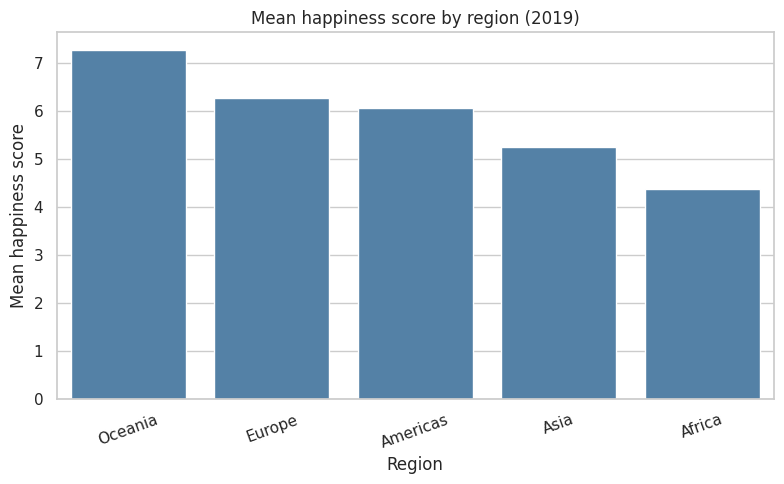

In [10]:
distributions.boxplot_by_region(df, year=2019)
geographic.bar_mean_by_region(df, year=2019)
plt.show()

### 4.3 Time evolution 2015 to 2019

The five-year window is too short to expect dramatic structural change, and the regional **mean trajectories** confirm it: every region moves within a narrow band of roughly \u00b10.2 score units between 2015 and 2019. There is no clear universal trend, which justifies treating each year as broadly comparable when we pool across years (e.g. the correlation matrix in 4.4).

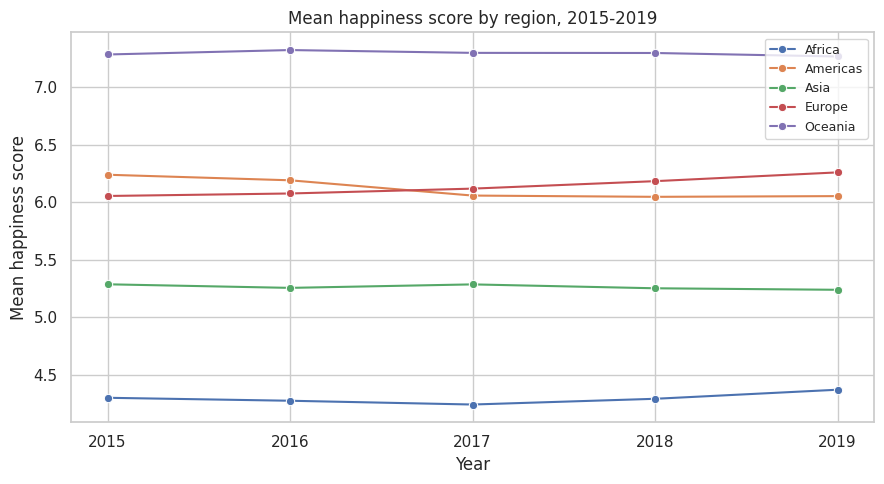

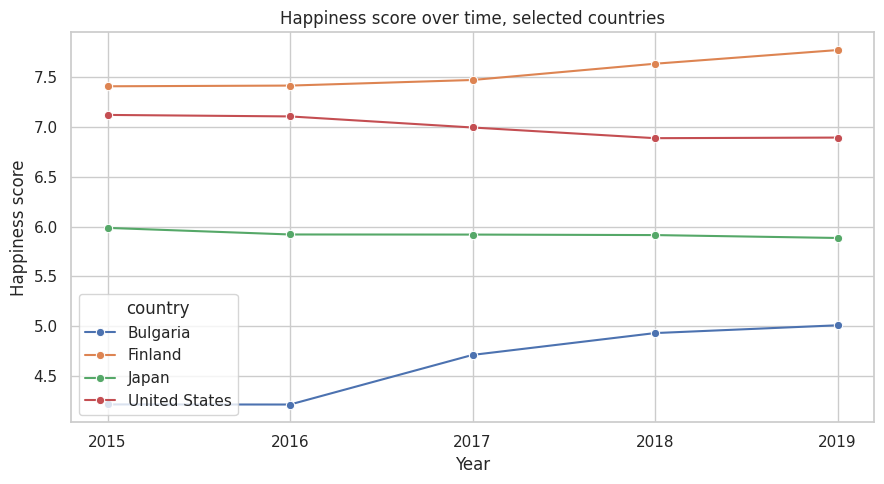

In [11]:
timeseries.lineplot_score_over_years(df, by='region')
plt.show()

# A handful of countries to sanity-check the trend at country level
timeseries.multi_country_trend(df, countries=['Bulgaria', 'Finland', 'United States', 'Japan'])
plt.show()

### 4.4 Correlation matrix

The pairwise Pearson matrix on the WHR factors plus the World Bank indicators surfaces three patterns worth highlighting:

- **GDP per capita PPP** is the strongest single correlate of the happiness `score` among the external indicators. This is the relationship we formalise as **H2**.
- The WHR's internal `gdp` factor and World Bank `gdp_ppp` are themselves strongly correlated (as expected, since the WHR derives the former from the latter via a log transform), so we treat them as redundant predictors and report only `gdp_ppp` in the regression test.
- `social_support` and `life_expectancy` correlate almost as strongly with `score` as `gdp` does, and they correlate heavily with each other — a textbook **multicollinearity** warning that we acknowledge but do not dwell on, because we only run univariate tests in section 5.

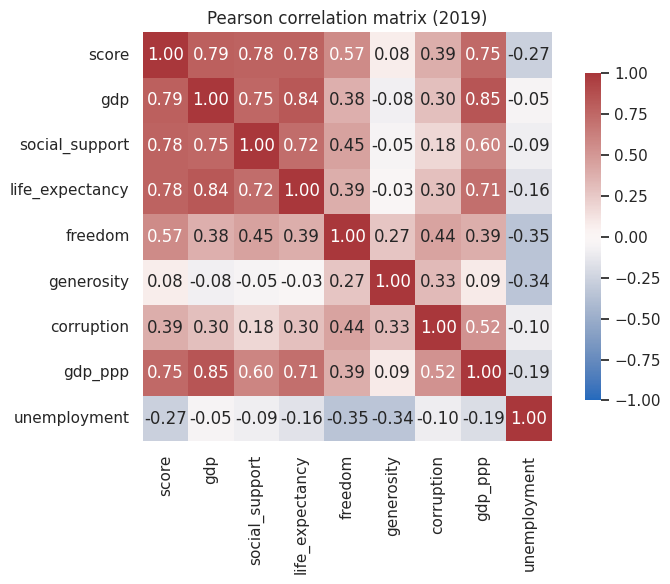

In [12]:
corr_cols = ['score', 'gdp', 'social_support', 'life_expectancy', 'freedom',
             'generosity', 'corruption', 'gdp_ppp', 'unemployment']
relationships.correlation_heatmap(df, columns=corr_cols, year=2019)
plt.show()

## 5. Hypothesis Testing

All tests use $\alpha = 0.05$ unless stated otherwise.

### 5.1 H1 — Western Europe vs Sub-Saharan Africa

**Test:** independent two-sample t-test (Welch's, unequal variances).

- $H_0$: mean 2019 happiness scores are equal in **Western & Northern Europe** and in **Sub-Saharan Africa**.
- $H_1$: the means differ.
- $\alpha = 0.05$.

**Group definitions.** REST Countries v3.1 splits Europe into six finer subregions and does not have a "Sub-Saharan Africa" label, so we operationalize the comparison as:

- **Western & Northern Europe** = `subregion ∈ {Western Europe, Northern Europe}` (the wealthy democracies — Nordics, UK/Ireland, France, Germany, Benelux, Switzerland, the Baltics).
- **Sub-Saharan Africa** = `region == 'Africa'` excluding `subregion == 'Northern Africa'`.

**Assumption check.** Welch's t-test does not require equal variances; it does benefit from approximately normal samples (or large enough n for the CLT). We verify normality with Shapiro–Wilk and report Levene's test for completeness.

In [13]:
d19 = df.query('year == 2019')
we_mask = d19['subregion'].isin(['Western Europe', 'Northern Europe'])
ssa_mask = (d19['region'] == 'Africa') & (d19['subregion'] != 'Northern Africa')

group_we = d19.loc[we_mask, 'score']
group_ssa = d19.loc[ssa_mask, 'score']

print(f'Western & Northern Europe: n={len(group_we)}, mean={group_we.mean():.3f}, sd={group_we.std(ddof=1):.3f}')
print(f'Sub-Saharan Africa:        n={len(group_ssa)}, mean={group_ssa.mean():.3f}, sd={group_ssa.std(ddof=1):.3f}')
print()
print(f"Shapiro-Wilk WE  p={stats.shapiro(group_we).pvalue:.4f}  (H0: normal)")
print(f"Shapiro-Wilk SSA p={stats.shapiro(group_ssa).pvalue:.4f}  (H0: normal)")
print(f"Levene           p={stats.levene(group_we, group_ssa).pvalue:.4f}  (H0: equal variances)")
print()
t_stat, p_val = stats.ttest_ind(group_we, group_ssa, equal_var=False)
print(f"Welch's t-test:  t = {t_stat:.4f},  p = {p_val:.3e}")

Western & Northern Europe: n=16, mean=7.023, sd=0.596
Sub-Saharan Africa:        n=40, mean=4.300, sd=0.625

Shapiro-Wilk WE  p=0.0489  (H0: normal)
Shapiro-Wilk SSA p=0.5571  (H0: normal)
Levene           p=0.8634  (H0: equal variances)

Welch's t-test:  t = 15.2223,  p = 2.410e-15


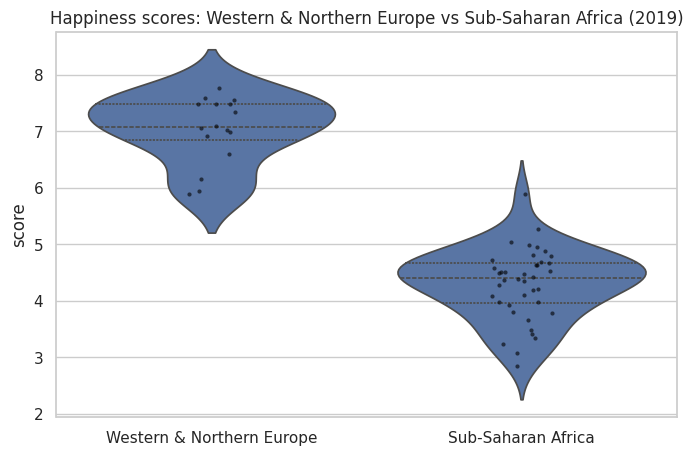

In [14]:
h1_subset = d19[we_mask | ssa_mask].copy()
h1_subset['group'] = h1_subset.apply(
    lambda r: 'Western & Northern Europe' if r['subregion'] in ('Western Europe', 'Northern Europe')
              else 'Sub-Saharan Africa',
    axis=1,
)
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=h1_subset, x='group', y='score', inner='quartile', ax=ax)
sns.stripplot(data=h1_subset, x='group', y='score', color='black', size=3, alpha=0.6, ax=ax)
ax.set_title("Happiness scores: Western & Northern Europe vs Sub-Saharan Africa (2019)")
ax.set_xlabel('')
plt.show()

**Result.** The two groups are virtually disjoint: every Western/Northern European country (n=16) scores between 5.9 and 7.8, and every Sub-Saharan country (n=40) scores between roughly 2.9 and 5.5, with means of **7.02** and **4.30** respectively. Welch's t = **15.22**, p ≈ **2.4 × 10⁻¹⁵**, far below $\alpha = 0.05$. Levene's test (p ≈ 0.86) supports approximately equal variances; Shapiro–Wilk on the Sub-Saharan group is comfortably non-significant (p ≈ 0.56), and the Western/Northern Europe group is borderline (p ≈ 0.05) but the sample is small enough that this borderline result does not invalidate Welch's test, which is robust to mild non-normality at these sample sizes.

**Decision.** Reject $H_0$. The mean happiness score in Western & Northern Europe is significantly higher than in Sub-Saharan Africa, by roughly **2.7 score points** (about four standard deviations of within-group variation).

### 5.2 H2 — GDP per capita predicts happiness

**Test:** Pearson product-moment correlation, with the associated two-sided p-value derived from the t-distribution under $H_0$.

- $H_0$: $\rho = 0$ — happiness score is linearly **independent** of (log) GDP per capita PPP.
- $H_1$: $\rho \neq 0$.
- $\alpha = 0.05$.

**Why log-GDP.** GDP per capita is heavily right-skewed (a few high-income countries are 100× the income of low-income ones), and a long line of empirical work — including the WHR itself — finds that happiness rises roughly **linearly with the logarithm** of income, not with raw income. We therefore correlate `score` with `ln(gdp_ppp)` and report the raw-GDP version as a sanity check.

In [15]:
h2_subset = d19.dropna(subset=['gdp_ppp', 'score']).copy()
h2_subset['log_gdp_ppp'] = np.log(h2_subset['gdp_ppp'])

r_log, p_log = stats.pearsonr(h2_subset['log_gdp_ppp'], h2_subset['score'])
r_raw, p_raw = stats.pearsonr(h2_subset['gdp_ppp'], h2_subset['score'])

print(f"n = {len(h2_subset)} countries (after dropping {d19.shape[0] - len(h2_subset)} with missing GDP)")
print(f"Pearson r (log GDP PPP vs score): r = {r_log:.4f},  p = {p_log:.3e}")
print(f"Pearson r (raw GDP PPP vs score): r = {r_raw:.4f},  p = {p_raw:.3e}")

n = 152 countries (after dropping 4 with missing GDP)
Pearson r (log GDP PPP vs score): r = 0.8079,  p = 2.907e-36
Pearson r (raw GDP PPP vs score): r = 0.7470,  p = 2.208e-28


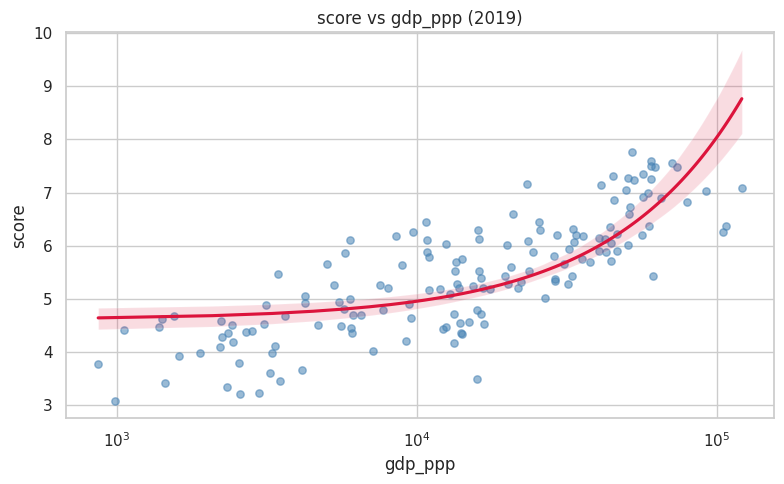

In [16]:
relationships.scatter_with_regression(df, x='gdp_ppp', y='score', year=2019, log_x=True)
plt.show()

**Result.** With $n = 152$ countries, Pearson **r ≈ 0.81** between `score` and `ln(gdp_ppp)`, p ≈ **2.9 × 10⁻³⁶**. The raw-GDP version is weaker (r ≈ 0.75) but still highly significant — confirming both that the relationship exists and that the log transform captures it more tightly. The scatter plot shows a clean, near-linear trend on a log-x axis, with most of the residual scatter sitting in the middle-income band ($5{,}000–$25{,}000 PPP), where culture, governance, and conflict can still pull happiness scores far from what income alone would predict.

**Decision.** Reject $H_0$. There is a strong positive linear association between log GDP per capita PPP and the WHR happiness score; with $r^2 \approx 0.65$, log income alone explains roughly two thirds of the cross-country variance in self-reported happiness in 2019.

### 5.3 H3 — Income group vs happiness class

**Test:** Pearson chi-squared test of independence on a $4 \times 2$ contingency table.

- Rows: World Bank **income group** ∈ {`Low income`, `Lower middle income`, `Upper middle income`, `High income`}.
- Columns: **happiness class** = `high` if a country's 2019 score is above the global median, otherwise `low`.

- $H_0$: income group and happiness class are statistically **independent**.
- $H_1$: income group and happiness class are **dependent**.
- $\alpha = 0.05$.

**Why this is not a duplicate of H2.** H2 tests a *linear* association on the score's continuous scale and is dominated by the GDP/score regression line. H3 categorises both axes and asks the weaker, more robust question: do *categories of wealth* shift the *distribution* of happiness across the global median? The chi-squared test is appropriate here because we are dealing with two categorical variables.

**Assumption check.** The chi-squared test requires expected cell counts $\geq 5$. We verify this from the output of `chi2_contingency` before reading the p-value.

In [17]:
h3_subset = d19.dropna(subset=['income_group', 'score']).copy()
h3_subset['happiness_class'] = (
    (h3_subset['score'] > h3_subset['score'].median())
    .map({True: 'high', False: 'low'})
)

income_order = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']
table = pd.crosstab(h3_subset['income_group'], h3_subset['happiness_class']).reindex(income_order)
print('Contingency table (n =', len(h3_subset), 'countries):')
print(table)
print()
chi2, p_val, dof, expected = stats.chi2_contingency(table)
print(f"Chi-squared = {chi2:.4f},  p = {p_val:.3e},  dof = {dof}")
print(f"Min expected cell count = {expected.min():.2f}  (required >= 5)")

Contingency table (n = 153 countries):
happiness_class      high  low
income_group                  
Low income              0   21
Lower middle income     7   34
Upper middle income    19   20
High income            50    2

Chi-squared = 83.1108,  p = 6.601e-18,  dof = 3
Min expected cell count = 10.43  (required >= 5)


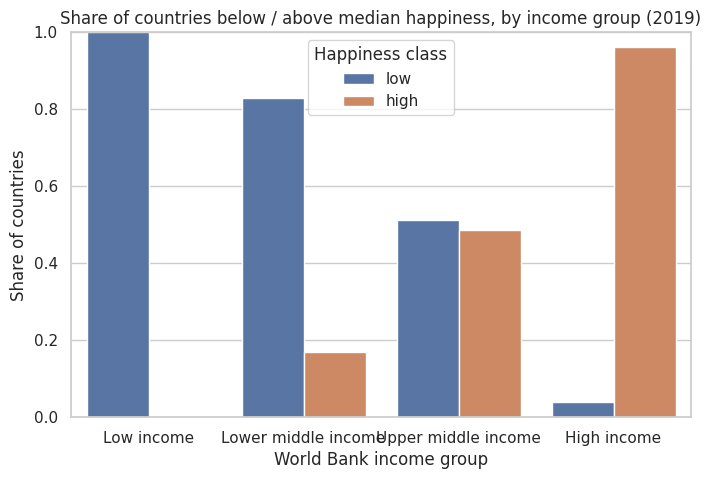

In [18]:
prop = (
    table.div(table.sum(axis=1), axis=0)
         .reset_index()
         .melt(id_vars='income_group', var_name='happiness_class', value_name='share')
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=prop,
    x='income_group',
    y='share',
    hue='happiness_class',
    hue_order=['low', 'high'],
    order=income_order,
    ax=ax,
)
ax.set_ylabel('Share of countries')
ax.set_xlabel('World Bank income group')
ax.set_title('Share of countries below / above median happiness, by income group (2019)')
ax.set_ylim(0, 1)
ax.legend(title='Happiness class')
plt.show()

**Result.** With $n = 153$ countries and a $4 \times 2$ table, $\chi^2 = 83.11$, dof $= 3$, p ≈ **6.6 × 10⁻¹⁸**. The smallest expected cell count is ≈ 10, comfortably above the conventional minimum of 5, so the chi-squared approximation is valid.

The pattern in the contingency table is dramatic:

- **High-income** countries: 50 above the median, only 2 below.
- **Low-income** countries: 0 above the median, 21 below.
- The middle-income groups straddle the median, with `Upper middle` already roughly 50/50 and `Lower middle` heavily skewed below.

**Decision.** Reject $H_0$. Income group and happiness class are *not* independent; rising up the World Bank income ladder dramatically raises the probability that a country sits in the upper half of the global happiness distribution. This is consistent with H2 but expresses the result on a more conservative, categorical basis.

## 6. Conclusions

_TODO: synthesize the three test outcomes and what they collectively say about the drivers of national happiness._

## 7. Summary

_TODO: TL;DR of the entire study (3-4 bullet points)._

## 8. References

1. Helliwell, J. F., Layard, R., Sachs, J. D. _World Happiness Report_ 2015–2019 editions. https://worldhappiness.report/data/
2. World Bank. _World Development Indicators_. https://data.worldbank.org/
3. REST Countries. https://restcountries.com/
4. SciPy `scipy.stats` documentation. https://docs.scipy.org/doc/scipy/reference/stats.html
5. McKinney, W. _Python for Data Analysis_. O'Reilly, 3rd ed., 2022.